# Notebook 5 — Final Comparison and Analysis

Goal: evaluate both models, produce all comparison plots and the results table.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import sys
sys.path.append('..')
from src.metrics import evaluate, evaluate_by_rul_range
from src.models.transformer_model import PositionalEncoding, TransformerEncoderBlock

DATA_DIR   = '../data/processed'
MODEL_DIR  = '../saved_models'
RESULT_DIR = '../experiments/results'
PLOT_DIR   = '../plots'

import os
os.makedirs(RESULT_DIR, exist_ok=True)

In [2]:
custom_objects = {
    'PositionalEncoding': PositionalEncoding,
    'TransformerEncoderBlock': TransformerEncoderBlock,
}

rows = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    X_test = np.load(f'{DATA_DIR}/X_test_{fd}.npy')
    y_test = np.load(f'{DATA_DIR}/y_test_{fd}.npy')

    for arch in ['lstm', 'transformer']:
        model = tf.keras.models.load_model(
            f'{MODEL_DIR}/{arch}_{fd}.keras',
            custom_objects=custom_objects if arch == 'transformer' else None
        )
        y_pred = model.predict(X_test, verbose=0).flatten()
        m = evaluate(y_test, y_pred)
        rows.append({'model': arch.upper(), 'dataset': fd, **m})
        print(f'{arch.upper()} {fd}: RMSE={m["rmse"]:.2f}, MAE={m["mae"]:.2f}, Score={m["nasa_score"]:.0f}')

results_df = pd.DataFrame(rows)
results_df.to_csv(f'{RESULT_DIR}/main_comparison.csv', index=False)
results_df

2026-05-11 22:08:54.475266: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-05-11 22:08:54.475339: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-11 22:08:54.475350: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-11 22:08:54.475428: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-11 22:08:54.475444: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-05-11 22:08:55.445695: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


LSTM FD001: RMSE=14.82, MAE=10.92, Score=387


/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement 

TRANSFORMER FD001: RMSE=15.50, MAE=11.75, Score=489
LSTM FD002: RMSE=29.29, MAE=19.03, Score=59884


/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implemen

...

/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implemen

TRANSFORMER FD003: RMSE=15.26, MAE=11.47, Score=407
LSTM FD004: RMSE=28.70, MAE=20.41, Score=7771


/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_7', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implemen

TRANSFORMER FD004: RMSE=39.36, MAE=23.97, Score=2369434


,model,dataset,rmse,mae,nasa_score
0,LSTM,FD001,14.815887,10.919986,3.872504e+02
1,TRANSFORMER,FD001,15.503721,11.747445,4.885556e+02
2,LSTM,FD002,29.287155,19.026335,5.988447e+04
3,TRANSFORMER,FD002,29.447838,18.440281,3.679730e+05
4,LSTM,FD003,15.607598,11.710323,3.925551e+02
5,TRANSFORMER,FD003,15.260942,11.469172,4.073940e+02
6,LSTM,FD004,28.700426,20.412830,7.770657e+03
7,TRANSFORMER,FD004,39.355518,23.967466,2.369434e+06


/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/Users/antonio/Desktop/UNI/Deep Learning/Temporal-Deep-Learning-for-Predictive-Maintenance/venv/lib/python3.11/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'transformer_encoder_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement 

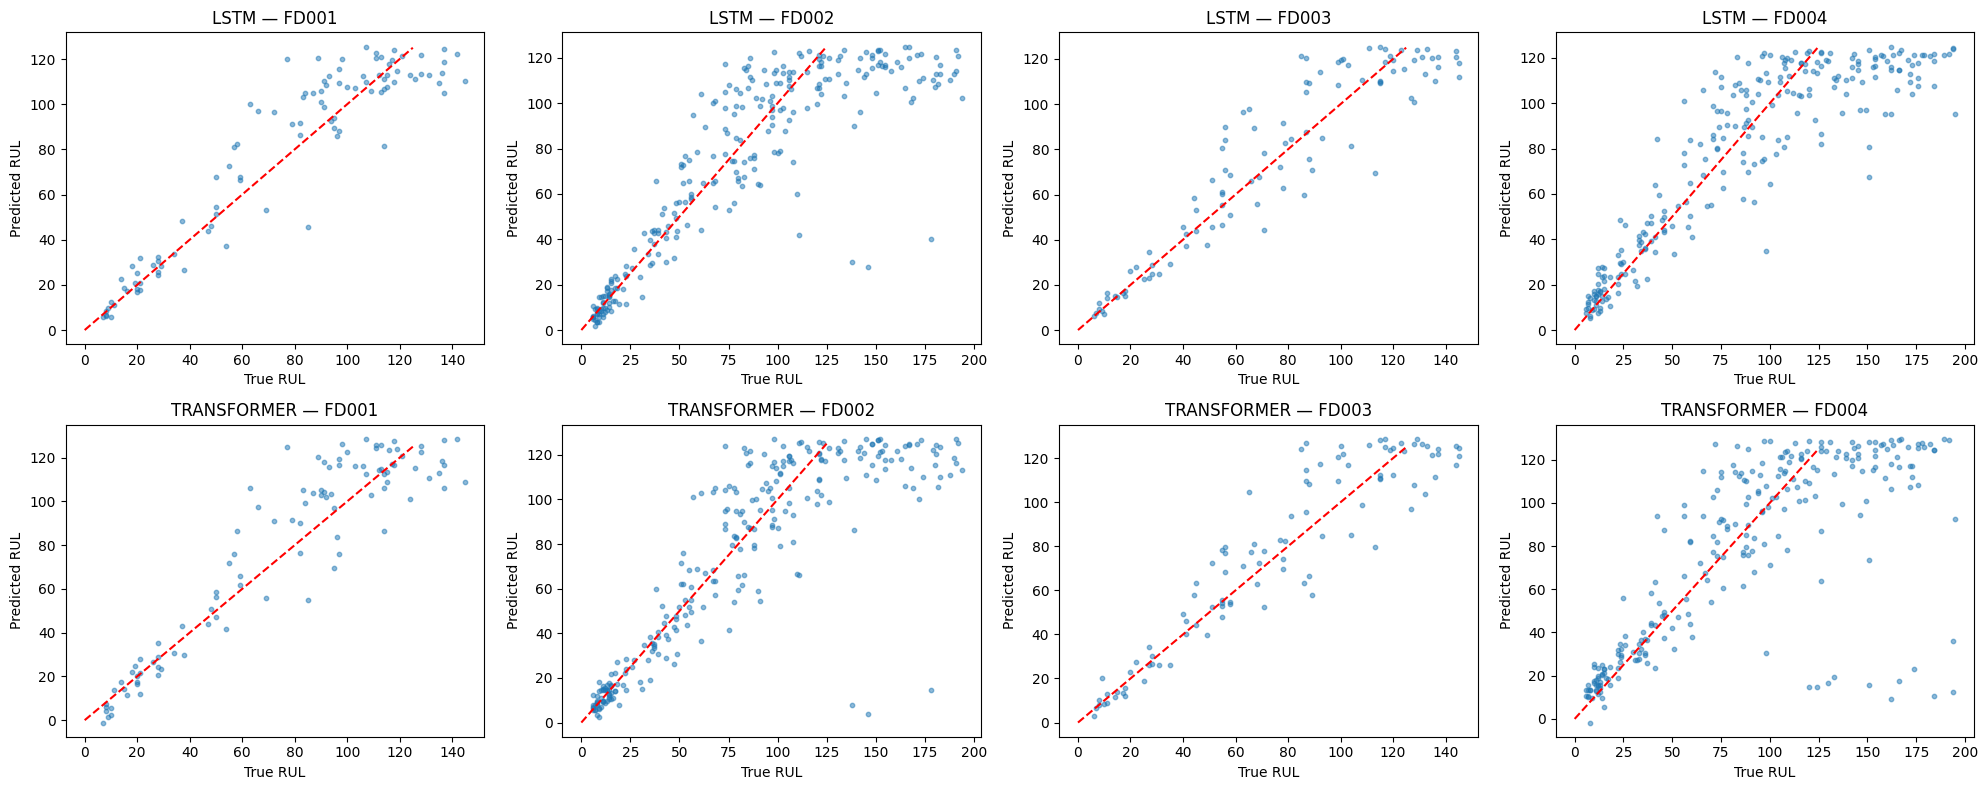

In [3]:
# Predicted vs True RUL — scatter plots
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for col, fd in enumerate(['FD001', 'FD002', 'FD003', 'FD004']):
    X_test = np.load(f'{DATA_DIR}/X_test_{fd}.npy')
    y_test = np.load(f'{DATA_DIR}/y_test_{fd}.npy')
    for row, arch in enumerate(['lstm', 'transformer']):
        model = tf.keras.models.load_model(
            f'{MODEL_DIR}/{arch}_{fd}.keras',
            custom_objects=custom_objects if arch == 'transformer' else None
        )
        y_pred = model.predict(X_test, verbose=0).flatten()
        ax = axes[row, col]
        ax.scatter(y_test, y_pred, alpha=0.5, s=10)
        ax.plot([0, 125], [0, 125], 'r--')
        ax.set_title(f'{arch.upper()} — {fd}')
        ax.set_xlabel('True RUL')
        ax.set_ylabel('Predicted RUL')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/05_scatter_pred_vs_true.png', dpi=150)
plt.show()

In [4]:
# RUL range analysis (Experiment 3)
range_rows = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    X_test = np.load(f'{DATA_DIR}/X_test_{fd}.npy')
    y_test = np.load(f'{DATA_DIR}/y_test_{fd}.npy')
    for arch in ['lstm', 'transformer']:
        model = tf.keras.models.load_model(
            f'{MODEL_DIR}/{arch}_{fd}.keras',
            custom_objects=custom_objects if arch == 'transformer' else None
        )
        y_pred = model.predict(X_test, verbose=0).flatten()
        by_range = evaluate_by_rul_range(y_test, y_pred)
        for rng, m in by_range.items():
            range_rows.append({'model': arch.upper(), 'dataset': fd, 'rul_range': rng, **m})

range_df = pd.DataFrame(range_rows)
range_df.to_csv(f'{RESULT_DIR}/rul_range_analysis.csv', index=False)
range_df

,model,dataset,rul_range,mae,rmse,n
0,LSTM,FD001,0-50,3.933405,5.665715,33
1,LSTM,FD001,50-100,16.428465,19.423494,37
2,LSTM,FD001,100-125,7.247869,9.922529,23
3,TRANSFORMER,FD001,0-50,4.423944,5.146971,33
4,TRANSFORMER,FD001,50-100,17.995687,20.842640,37
5,TRANSFORMER,FD001,100-125,9.369740,12.235471,23
6,LSTM,FD002,0-50,4.564586,6.192588,88
7,LSTM,FD002,50-100,16.400631,19.511108,80
8,LSTM,FD002,100-125,12.804544,18.712597,36
9,TRANSFORMER,FD002,0-50,4.339110,6.252760,88
